# Testing for the sample waypoint / mission plannig data 

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

def find_root_path(path: str, word: str):
    parts = path.split(word, 1)
    return parts[0] + word if len(parts) > 1 else path

root_folder = Path(find_root_path(os.getcwd(), 'art_lang'))
sys.path.append(str(root_folder))


In [ ]:
# 1) Load the datafile (.pth)
data_path = root_folder / 'rpod' / 'rages' / 'data_v2.pth'
dataset = torch.load(data_path, map_location='cpu')
data = dataset['data']
stats = dataset['stats']
meta = dataset['meta']

N = int(data['x0'].shape[0])
print(f"Loaded {N} data points from {data_path}.")
print("meta:", meta)


Loaded 30 data points from /home/yuji/github/art_lang/rpod/rages/wyp_data/data_v2.pth.
meta: {'num_samples': 30, 'max_phase': 3, 'oe_dim': 10, 'koz_dim': 3, 'artms_dim': 6, 'dt_sec': 900.0, 'n_time_max': 100, 'reward_shift': 5.714648796081543}


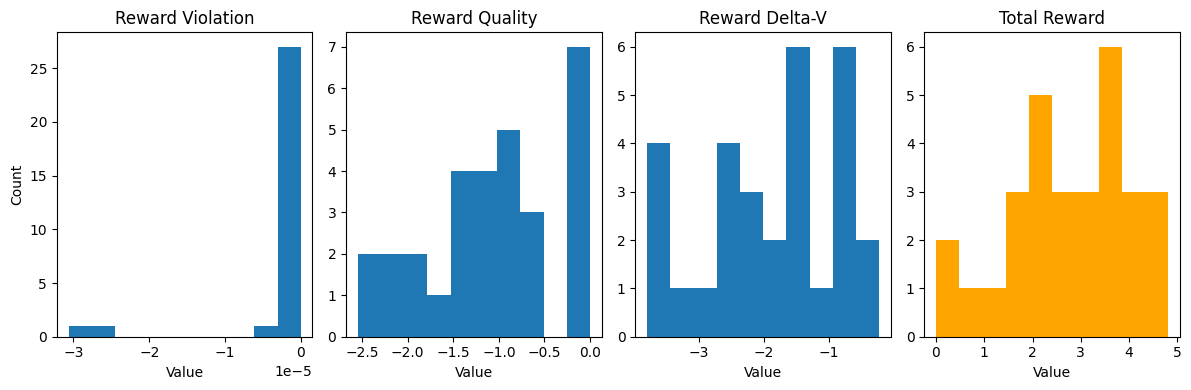

In [5]:
r_viol = data['reward_violation'].numpy()
r_qual = data['reward_quality'].numpy()
r_dv = data['reward_dv'].numpy()
r_tot = data['reward'].numpy()

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(1, 4, 1)
ax2 = fig.add_subplot(1, 4, 2)
ax3 = fig.add_subplot(1, 4, 3)
ax4 = fig.add_subplot(1, 4, 4)

ax1.hist(r_viol, bins=10)
ax1.set_title('Reward Violation')
ax1.set_xlabel('Value')
ax1.set_ylabel('Count')
ax2.hist(r_qual, bins=10)
ax2.set_title('Reward Quality')
ax2.set_xlabel('Value')
ax3.hist(r_dv, bins=10)
ax3.set_title('Reward Delta-V')
ax3.set_xlabel('Value')
ax4.hist(r_tot, bins=10, color='orange')
ax4.set_title('Total Reward')
ax4.set_xlabel('Value')
fig.tight_layout()


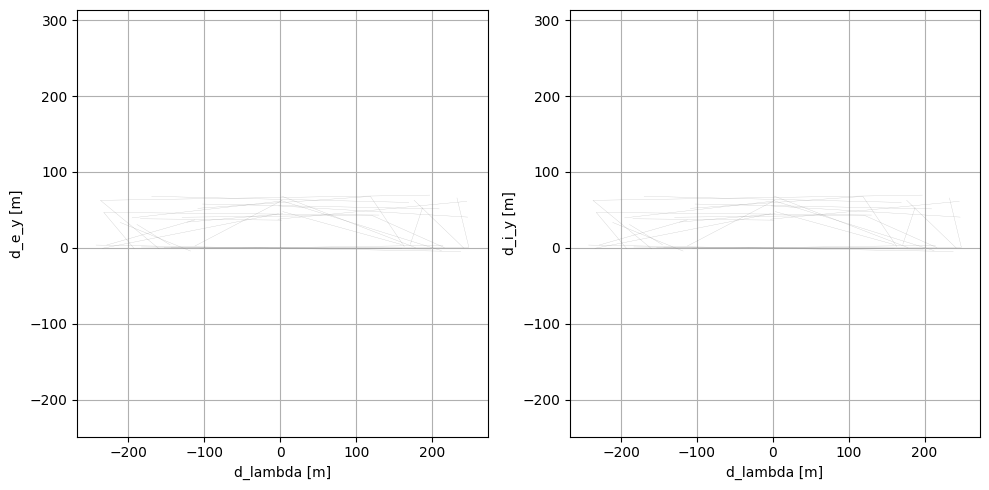

In [6]:
x_seq = data['x_seq'].numpy()
phase_valid = data['phase_valid'].numpy().astype(bool)

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

for i in range(x_seq.shape[0]):
    n = int(phase_valid[i].sum())
    if n == 0:
        continue
    xs = x_seq[i, :n]
    ax1.plot(xs[:, 1], xs[:, 3], linewidth=0.2, alpha=0.5, color='grey')
    ax2.plot(xs[:, 1], xs[:, 5], linewidth=0.2, alpha=0.5, color='grey')

ax1.set_xlabel("d_lambda [m]")
ax1.set_ylabel("d_e_y [m]")
ax1.grid()
ax1.axis('equal')

ax2.set_xlabel("d_lambda [m]")
ax2.set_ylabel("d_i_y [m]")
ax2.grid()
ax2.axis('equal')

fig.tight_layout()


In [7]:
oec_modified = data['oec0_modified'].numpy()


In [9]:
torch.sum(data["dt_seq"], dim=1)

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])